# CIFAR-10

In [3]:
import torch
from torchvision.datasets import CIFAR10
from torchvision import transforms

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
device

device(type='mps')

In [5]:
train_cifar10 = CIFAR10(root='../../data', train=True, transform=None, download=True)

In [6]:
type(train_cifar10)
# torchvision.datasets.cifar.CIFAR10

torchvision.datasets.cifar.CIFAR10

In [7]:
type(train_cifar10.data)
# numpy.ndarray

numpy.ndarray

In [8]:
train_cifar10.data.shape
# (50000, 32, 32, 3)

(50000, 32, 32, 3)

In [9]:
train_cifar10.data.dtype
# dtype('uint8')

dtype('uint8')

In [10]:
image = train_cifar10.data[0]

In [11]:
image.shape
# (32, 32, 3)

(32, 32, 3)

In [12]:
from plt_rcs import *

In [13]:
train_cifar10.targets[0]
# 6

6

In [14]:
train_cifar10.classes
# ['airplane',
#  'automobile',
#  'bird',
#  'cat',
#  'deer',
#  'dog',
#  'frog',
#  'horse',
#  'ship',
#  'truck']

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [15]:
train_cifar10.class_to_idx
# {'airplane': 0,
#  'automobile': 1,
#  'bird': 2,
#  'cat': 3,
#  'deer': 4,
#  'dog': 5,
#  'frog': 6,
#  'horse': 7,
#  'ship': 8,
#  'truck': 9}

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

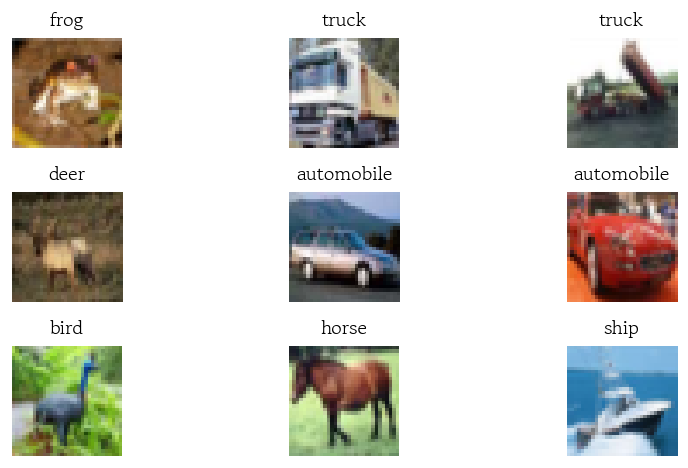

In [16]:
for i in range(9):
    plt.subplot(3, 3, i+1)
    image = train_cifar10.data[i]
    plt.imshow(X=image)
    target = train_cifar10.targets[i]
    plt.title(label=f'{train_cifar10.classes[target]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 훈련셋의 채널별 평균과 표준편차 계산

In [17]:
# 훈련셋을 실수형 텐서로 변환 후 0~1 범위로 스케일링
pixels = torch.from_numpy(train_cifar10.data).float() / 255

In [18]:
# 형태 확인
pixels.shape
# torch.Size([50000, 32, 32, 3])

torch.Size([50000, 32, 32, 3])

In [19]:
# 채널별 평균 확인
pixels.mean(dim=(0, 1, 2))
# tensor([0.4914, 0.4822, 0.4465])

tensor([0.4914, 0.4822, 0.4465])

In [20]:
# 채널별 표준편차 확인
pixels.std(dim=(0, 1, 2))
# tensor([0.2470, 0.2435, 0.2616])

tensor([0.2470, 0.2435, 0.2616])

## 이미지 변환 객체 생성

In [21]:
cifar10_avg = [round(v.item(), 4) for v in pixels.mean(dim=(0, 1, 2))]
cifar10_std = [round(v.item(), 4) for v in pixels.std(dim=(0, 1, 2))]

In [22]:
# 정규화를 포함한 이미지 변환 객체 생성
transform = transforms.Compose(
    transforms=[
        transforms.ToTensor(),
        transforms.Normalize(mean=cifar10_avg, std=cifar10_std)
    ]
)

In [23]:
train_cifar10 = CIFAR10(root='../../data', train=True, transform=transform)

In [24]:
image, label = train_cifar10[0]

In [25]:
type(image)
# torch.Tensor

torch.Tensor

In [26]:
image.shape
# torch.Size([3, 32, 32])

torch.Size([3, 32, 32])

## 역정규화 함수 생성

In [27]:
def denormalize_tensor(image, avg, std):
    avg = torch.tensor(data=avg, device=image.device).reshape(3, 1, 1)
    std = torch.tensor(data=std, device=image.device).reshape(3, 1, 1)
    image = image * std + avg
    image = image.clamp(min=0, max=1)
    image = (image * 255).round().to(torch.uint8)
    return image

In [28]:
image = denormalize_tensor(image=image, avg=cifar10_avg, std=cifar10_std)
image = image.permute(1, 2, 0)
image.shape
# torch.Size([32, 32, 3])

torch.Size([32, 32, 3])

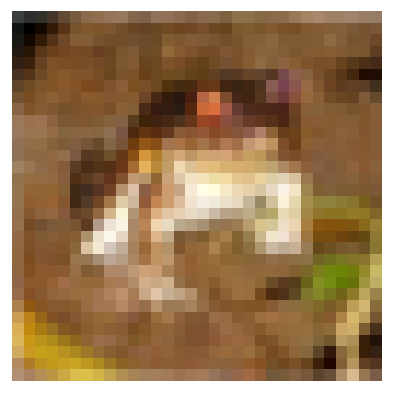

In [29]:
plt.imshow(X=image)
plt.axis('off');

## 시험셋 준비

In [30]:
test_cifar10 = CIFAR10(root='../../data', train=False, transform=transform)

## 외부 파일로 저장

In [31]:
import os
import pandas as pd

In [32]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/dl'

In [33]:
os.chdir('../../data')

In [34]:
pd.to_pickle(
    obj={
        'train_cifar10': train_cifar10,
        'test_cifar10': test_cifar10
    }, filepath_or_buffer='CIFAR10_Dataset.pkl'
)

- CIFAR10 image shape : (3, 32, 32)
- block 1 : Conv2 - Conv 2 - Pool
- block 2 : Conv2 - Conv 2 - Pool
- block 3 : Conv2 - Conv 2 - Pool
- classifier : FC

In [35]:
import torch.nn as nn

In [36]:
model = nn.Sequential(
    # block 1 : (3, 32, 32) -> (64, 32, 32) -> (64, 16, 16)
    nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    # block 2 : (64, 16, 16) -> (128, 16, 16) -> (128, 8, 8)
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    # block 3 : (128, 8, 8) -> (256, 8, 8) -> (256, 4, 4)
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    # classifier : (256, 4, 4) -> 256 -> 10
    nn.Flatten(),
    nn.Linear(in_features=256*4*4, out_features=256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(in_features=256, out_features=10)
)

In [37]:
# 모델에서 학습 가능한 파라미터 수 확인
sum([p.numel() for p in model.parameters() if p.requires_grad == True])

2196810